# Fashion MNIST – Klassificering av klädesplagg

## Sammanfattning
I det här projektet har vi byggt en klassificeringsmodell som identifierar 
klädesplagg från Fashion MNIST-datasetet. Modellen tar en 28x28 gråskalebild 
som input och förutsäger vilken av 10 klasser den tillhör.

Vårt fokusområde är **optimering och learning rate**. Vi har undersökt hur 
valet av optimerare påverkar hur snabbt och stabilt modellen lär sig.

## Vad vi testade
Vi tränade samma modellarkitektur med fem olika optimerare:
- SGD (låg learning rate: 0.001)
- SGD (learning rate: 0.01)
- SGD + Momentum (learning rate: 0.01, momentum: 0.9)
- Adam (learning rate: 0.001)
- AdamW (learning rate: 0.001, weight decay: 0.01)

Vi undersökte även overfitting och underfitting genom att träna Adam-modellen 
i 30 epoker, samt jämförde vår Dense-modell mot en CNN-modell.

## Resultat
| Optimizer | Test Accuracy |
|-----------|--------------|
| Adam | 87.33% |
| AdamW | 87.25% |
| SGD + Momentum | 87.15% |
| SGD | 85.42% |
| SGD (låg lr) | 79.79% |
| CNN (Adam) | 89.07% |

Adam och AdamW presterade bäst bland Dense-modellerna över 10 epoker, följda 
av SGD med momentum. CNN-modellen presterade bäst totalt med 89% accuracy.
Vi noterar att SGD fortfarande förbättrades vid epoch 10 och skulle kunna 
prestera bättre med fler epoker. Både Dense- och CNN-modellen visade tecken 
på overfitting efter circa epoch 6-10.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

## Modellarkitektur

Vi byggde ett fully connected neuralt nätverk (Dense layers) med följande struktur:

| Lager | Detaljer |
|-------|----------|
| Input | 28x28 pixlar (gråskala) |
| Flatten | Omformar bilden till en vektor av 784 värden |
| Dense | 128 neuroner, ReLU-aktivering |
| Dropout | 20% av neuroner stängs av slumpmässigt under träning |
| Dense | 10 neuroner, Softmax-aktivering (en per klass) |

### Våra val
**128 neuroner** i det dolda lagret är en balans mellan kapacitet och 
komplexitet – tillräckligt stort för att lära sig mönster i datan utan 
att bli onödigt tungt att träna.

**Dropout(0.2)** används för att minska risken för overfitting. Under 
träning stängs 20% av neuronerna av slumpmässigt, vilket tvingar nätverket 
att inte förlita sig för mycket på enskilda neuroner.

**Softmax** i outputlagret omvandlar nätverkets råa värden till 
sannolikheter för varje klass. Den klass med högst sannolikhet blir 
modellens förutsägelse.

### Dataförberedelse
Bildernas pixelvärden normaliserades från [0, 255] till [0, 1] genom 
att dividera med 255. Detta gör att träningen blir mer stabil eftersom 
nätverket hanterar små tal bättre än stora.

In [3]:
#Load dataseet

fashion_mnist = tf.keras.datasets.fashion_mnist

# Train och test uppdelning är redan hårdkodad av Zalando
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()



In [4]:
print(train_images.shape)
print(test_images.shape)

print(train_labels)


(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


In [5]:
# Klassnamn från https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [6]:
# Normalisera pixelvärden från [0, 255] till [0, 1]
train_images = train_images / 255.0

test_images = test_images / 255.0

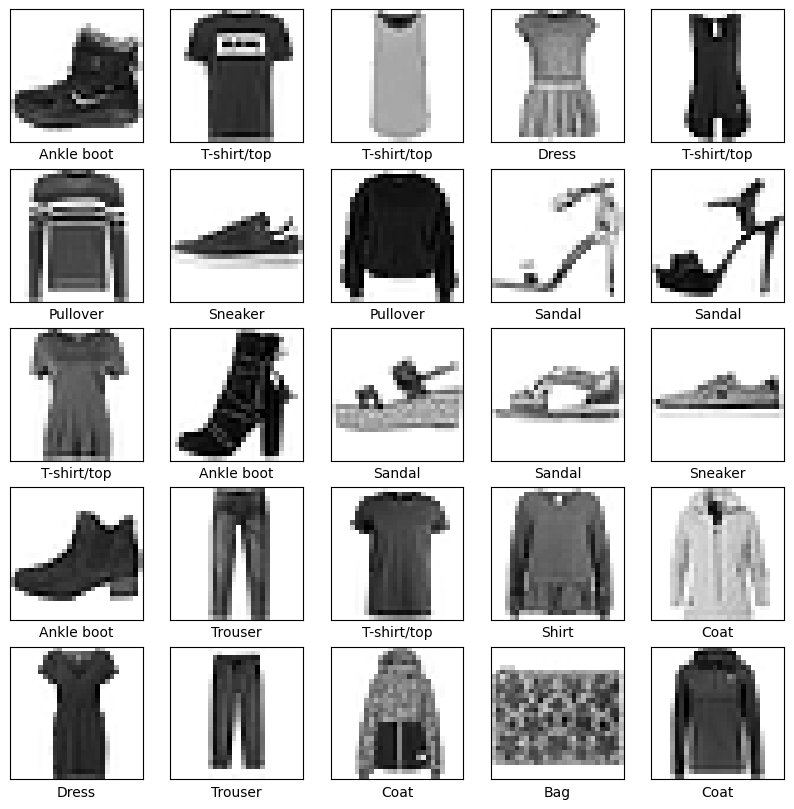

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [8]:
# Build neural network
# Keras default är batch size = 32

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),      # Valde 128 neuroner för att det är en vanlig storlek 
    Dropout(0.2),
    Dense(10, activation='softmax')     
])


In [9]:
# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Träning och validering

Alla modeller tränades med följande inställningar:
- 10 epochs
- Batch size: 32
- Validation split: 0.2 (20% av träningsdatan används för validering)

Det innebär att modellen i praktiken tränas på 48 000 bilder och 
valideras på 12 000 bilder per epoch. De 10 000 testbilderna används 
endast för den slutliga utvärderingen.

Observation: hoppig valideringskurva
Vid träning med Adam noterade vi att valideringskurvan studsade lite 
upp och ner mellan epochs, medan träningskurvan sjönk stadigt.

Detta är normalt och beror på två saker:
- Valideringsdatan är mindre (12 000 bilder) vilket gör kurvan känsligare 
  för slumpvariationer
- Dropout är aktiv under träning men avstängd vid validering, vilket 
  introducerar lite variation från epoch till epoch

In [10]:
# Train Model

history = model.fit(
    train_images,
    train_labels,
    epochs=10,              # Istället för att välja 10 epochs så kan vi kolla vilket nummer som är optimalt
    
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8040 - loss: 0.5559 - val_accuracy: 0.8518 - val_loss: 0.4142
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8503 - loss: 0.4141 - val_accuracy: 0.8619 - val_loss: 0.3782
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8640 - loss: 0.3739 - val_accuracy: 0.8694 - val_loss: 0.3616
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8700 - loss: 0.3533 - val_accuracy: 0.8778 - val_loss: 0.3370
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8769 - loss: 0.3349 - val_accuracy: 0.8736 - val_loss: 0.3481
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8800 - loss: 0.3230 - val_accuracy: 0.8818 - val_loss: 0.3255
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8851 - loss: 0.3093 - val_accuracy: 0.8792 - val_loss: 0.3307
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8885 - loss: 0.3018 - 

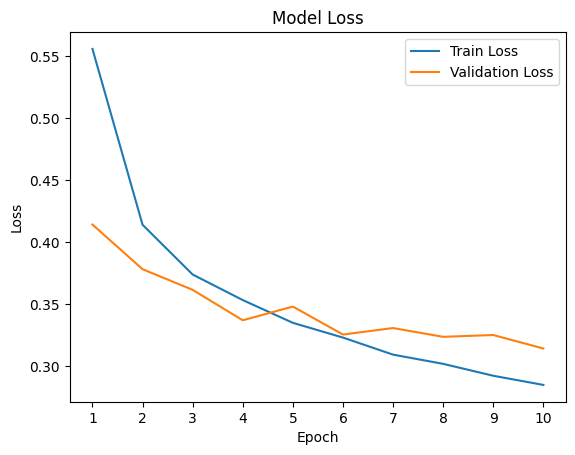

In [11]:
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.xticks(epochs)

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()


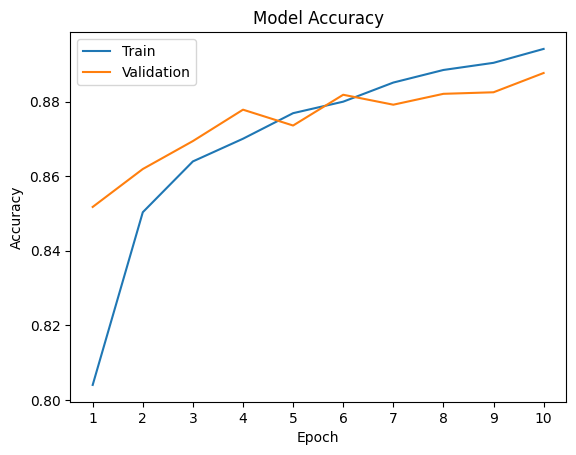

In [12]:
plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.show()


In [13]:
# Validation 

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels
)

print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.8780 - loss: 0.3409
Test accuracy: 0.878000020980835


## Overfitting och Underfitting

För att analysera modellens generaliseringsförmåga tränades Adam-modellen i 30 epochs.

I början av träningen förbättrades både tränings- och valideringsaccuracy snabbt, 
vilket tyder på att modellen fortfarande var underfittad och höll på att lära sig 
grundläggande mönster i datan.

Mellan ungefär epoch 5 och 6 låg tränings- och valideringskurvorna nära varandra, 
vilket indikerar god generalisering.

Efter cirka epoch 6 började dock tydliga tecken på overfitting synas:
- träningsaccuracy fortsatte öka
- träningsloss fortsatte minska
- valideringsaccuracy planade ut
- valideringsloss började variera och långsamt öka

Detta visar att modellen fortsatte optimera mot träningsdatan utan att förbättra 
sin prestation på ny data.

Dropout(0.2) hjälpte sannolikt till att begränsa overfitting, eftersom skillnaden 
mellan tränings- och valideringskurvorna fortfarande förblev relativt måttlig.

In [14]:
# Skapa en ny modell och optimera den, ta 30 epochs. 

model_uo = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model_uo.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_uo = model_uo.fit(
    train_images,
    train_labels,
    epochs=30,
    validation_split=0.2
)





Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7978 - loss: 0.5733 - val_accuracy: 0.8515 - val_loss: 0.4230
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8496 - loss: 0.4185 - val_accuracy: 0.8555 - val_loss: 0.4006
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8626 - loss: 0.3776 - val_accuracy: 0.8729 - val_loss: 0.3552
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8703 - loss: 0.3562 - val_accuracy: 0.8758 - val_loss: 0.3390
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8748 - loss: 0.3411 - val_accuracy: 0.8792 - val_loss: 0.3329
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8809 - loss: 0.3241 - val_accuracy: 0.8731 - val_loss: 0.3468
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8828 - loss: 0.3134 - val_accuracy: 0.8883 - val_loss: 0.3164
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8876 - loss: 0.3023 - 

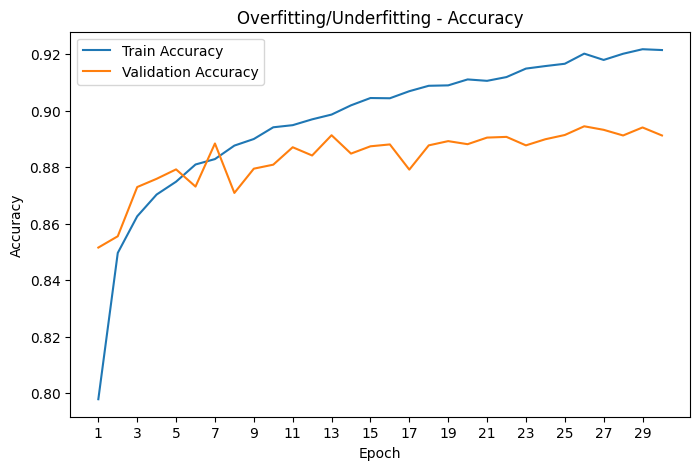

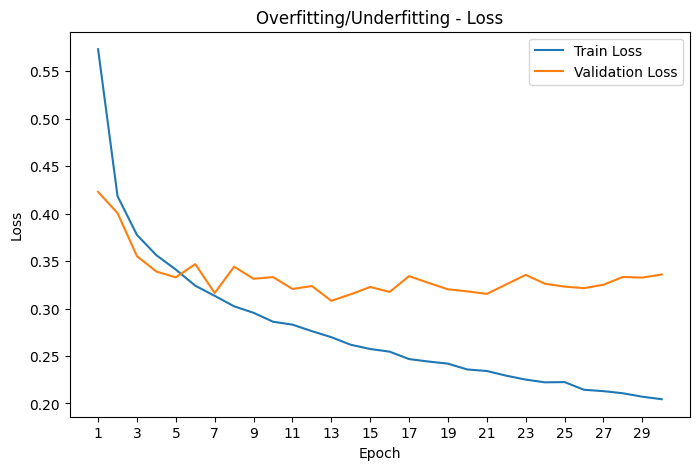

In [15]:
epochs = range(1, len(history_uo.history['loss']) + 1)

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(epochs, history_uo.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history_uo.history['val_accuracy'], label='Validation Accuracy')

plt.title("Overfitting/Underfitting - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs[::2])
plt.legend()

plt.show()

# Loss
plt.figure(figsize=(8,5))

plt.plot(epochs, history_uo.history['loss'], label='Train Loss')
plt.plot(epochs, history_uo.history['val_loss'], label='Validation Loss')

plt.title("Overfitting/Underfitting - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs[::2])
plt.legend()

plt.show()

## Analys av optimerare

Vi tränade samma modell fem gånger med olika optimerare för att kunna 
göra en rättvis jämförelse. Enda skillnaden mellan körningarna var 
valet av optimerare – arkitektur, antal epochs och batch size var identiska.

### SGD – Stochastic Gradient Descent
Vanlig SGD med learning rate 0.01 startade på 71.6% accuracy vid epoch 1 
och förbättrades stadigt till 85.4% vid epoch 10. Kurvan var jämn men 
långsam. Modellen var tydligt inte klar vid epoch 10 och hade förmodligen 
fortsatt förbättras med fler epochs.

### SGD med låg learning rate
Med learning rate 0.001 startade modellen på bara 51.8%, knappt bättre 
än slumpmässig gissning. Det här är det tydligaste exemplet på vad för
låg learning rate innebär i praktiken: modellen lär sig långsamt och
hinner inte konvergera på 10 epoker.

### SGD + Momentum
Momentum (0.9) gjorde en stor skillnad, Epoch 1 landade på 79.2% jämfört 
med SGDs 71.6%. Momentum fungerar som en boll som rullar nerför en backe: 
den accelererar i rätt riktning istället för att ta ett litet steg i taget. 
Slutresultatet (87.2%) var nästan identiskt med Adam.

### Adam
Adam kom igång snabbt (89.6% redan vid epoch 1) men planade ut tidigt. 
Valideringskurvan förbättrades knappt efter epoch 4. Det beror på att 
Adam automatiskt anpassar learning rate per parameter och bromsar in när 
den hittar ett bra område. Den "blev klar" betydligt tidigare än SGD.

### AdamW
AdamW är en förbättrad version av Adam som separerar weight decay från 
gradientuppdateringen korrekt. Resultatet (87.25%) var nästan identiskt 
med Adam på detta dataset. AdamWs fördel syns tydligare på större modeller 
och mer komplex data. 

### Slutsats
Adam och AdamW presterade bäst på kort sikt tack vare snabb konvergens. 
SGD med momentum kom nära samma slutresultat men behövde mer epochs för 
att komma dit. 

In [16]:
# Testar med SGD optimizer

# Skapa en Ny modell (viktigt för rätt jämförelse)
model_sgd = Sequential([
    Input(shape=(28, 28)),     # Input = 28x28 bild
    Flatten(),                 # Gör om bilden till en vektor
    Dense(128, activation='relu'),  # Dold lager
    Dropout(0.2),             # Regularisering (minskar overfitting)
    Dense(10, activation='softmax') # Output (10 klasser)
])

# SGD optimizer (utan momentum)
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

# Kompilera modellen
model_sgd.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Träna modellen
history_sgd = model_sgd.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

# Utvärdera på testdata
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_images, test_labels)

print("SGD Test accuracy:", test_acc_sgd)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.7054 - loss: 0.8713 - val_accuracy: 0.7926 - val_loss: 0.6048
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step - accuracy: 0.7959 - loss: 0.5957 - val_accuracy: 0.8234 - val_loss: 0.5222
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - accuracy: 0.8182 - loss: 0.5327 - val_accuracy: 0.8322 - val_loss: 0.4843
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.8301 - loss: 0.4968 - val_accuracy: 0.8340 - val_loss: 0.4729
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - accuracy: 0.8382 - loss: 0.4716 - val_accuracy: 0.8462 - val_loss: 0.4442
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.8440 - loss: 0.4517 - val_accuracy: 0.8520 - val_loss: 0.4277
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8472 - loss: 0.4357 - val_accuracy: 0.8482 - val_loss: 0.4279
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8522 -

In [17]:
model_sgd_low = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001
)

model_sgd_low.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_low = model_sgd_low.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_low, test_acc_sgd_low = model_sgd_low.evaluate(test_images, test_labels)

print("SGD (low LR) Test accuracy:", test_acc_sgd_low)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - accuracy: 0.5455 - loss: 1.5070 - val_accuracy: 0.6817 - val_loss: 1.0661
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.6703 - loss: 1.0093 - val_accuracy: 0.7181 - val_loss: 0.8587
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 894us/step - accuracy: 0.7049 - loss: 0.8740 - val_accuracy: 0.7451 - val_loss: 0.7692
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - accuracy: 0.7294 - loss: 0.8009 - val_accuracy: 0.7632 - val_loss: 0.7159
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.7458 - loss: 0.7538 - val_accuracy: 0.7762 - val_loss: 0.6790
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.7569 - loss: 0.7190 - val_accuracy: 0.7831 - val_loss: 0.6519
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.7669 - loss: 0.6933 - val_accuracy: 0.7918 - val_loss: 0.6294
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 0.7758 -

In [18]:
model_sgd_m = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_sgd_m.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_m = model_sgd_m.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_m, test_acc_sgd_m = model_sgd_m.evaluate(test_images, test_labels)

print("SGD + Momentum Test accuracy:", test_acc_sgd_m)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.7960 - loss: 0.5821 - val_accuracy: 0.8361 - val_loss: 0.4572
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - accuracy: 0.8414 - loss: 0.4346 - val_accuracy: 0.8388 - val_loss: 0.4242
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.8547 - loss: 0.4003 - val_accuracy: 0.8699 - val_loss: 0.3749
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 954us/step - accuracy: 0.8616 - loss: 0.3776 - val_accuracy: 0.8651 - val_loss: 0.3685
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.8681 - loss: 0.3601 - val_accuracy: 0.8684 - val_loss: 0.3558
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.8726 - loss: 0.3487 - val_accuracy: 0.8596 - val_loss: 0.3886
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.8749 - loss: 0.3392 - val_accuracy: 0.8774 - val_loss: 0.3396
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.8808 -

In [19]:
# Prövar AdamW med learning rate 0.001 och weight decay 0.01

model_adamw = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.01
)

model_adamw.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adamw = model_adamw.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_adamw, test_acc_adamw = model_adamw.evaluate(test_images, test_labels)

print("AdamW Test accuracy:", test_acc_adamw)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8048 - loss: 0.5537 - val_accuracy: 0.8538 - val_loss: 0.4072
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8506 - loss: 0.4110 - val_accuracy: 0.8618 - val_loss: 0.3849
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8646 - loss: 0.3735 - val_accuracy: 0.8685 - val_loss: 0.3600
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8702 - loss: 0.3529 - val_accuracy: 0.8630 - val_loss: 0.3714
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8756 - loss: 0.3388 - val_accuracy: 0.8756 - val_loss: 0.3412
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8784 - loss: 0.3268 - val_accuracy: 0.8788 - val_loss: 0.3319
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8809 - loss: 0.3169 - val_accuracy: 0.8751 - val_loss: 0.3385
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8885 - loss: 0.3036 - 

In [20]:
# Jämförelse av alla modeller

print("Adam:", test_acc)
print("SGD:", test_acc_sgd)
print("SGD (low LR):", test_acc_sgd_low)
print("SGD + Momentum:", test_acc_sgd_m)
print("AdamW:", test_acc_adamw)


Adam: 0.878000020980835
SGD: 0.8508999943733215
SGD (low LR): 0.7968000173568726
SGD + Momentum: 0.8743000030517578
AdamW: 0.8759999871253967


In [21]:
results = pd.DataFrame({
    'Optimizer': ['Adam', 'AdamW', 'SGD + Momentum', 'SGD', 'SGD (låg lr)'],
    'Learning Rate': [0.001, 0.001, 0.01, 0.01, 0.001],
    'Weight Decay': ['-', '0.01', '-', '-', '-'],
    'Test Accuracy': [test_acc, test_acc_adamw, test_acc_sgd_m, test_acc_sgd, test_acc_sgd_low]
})

results['Test Accuracy'] = results['Test Accuracy'].map('{:.2%}'.format)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print("\nAlla modeller tränade med 10 epochs och Keras default batch size 32")

     Optimizer  Learning Rate Weight Decay Test Accuracy
          Adam          0.001            -        87.80%
         AdamW          0.001         0.01        87.60%
SGD + Momentum          0.010            -        87.43%
           SGD          0.010            -        85.09%
  SGD (låg lr)          0.001            -        79.68%

Alla modeller tränade med 10 epochs och Keras default batch size 32


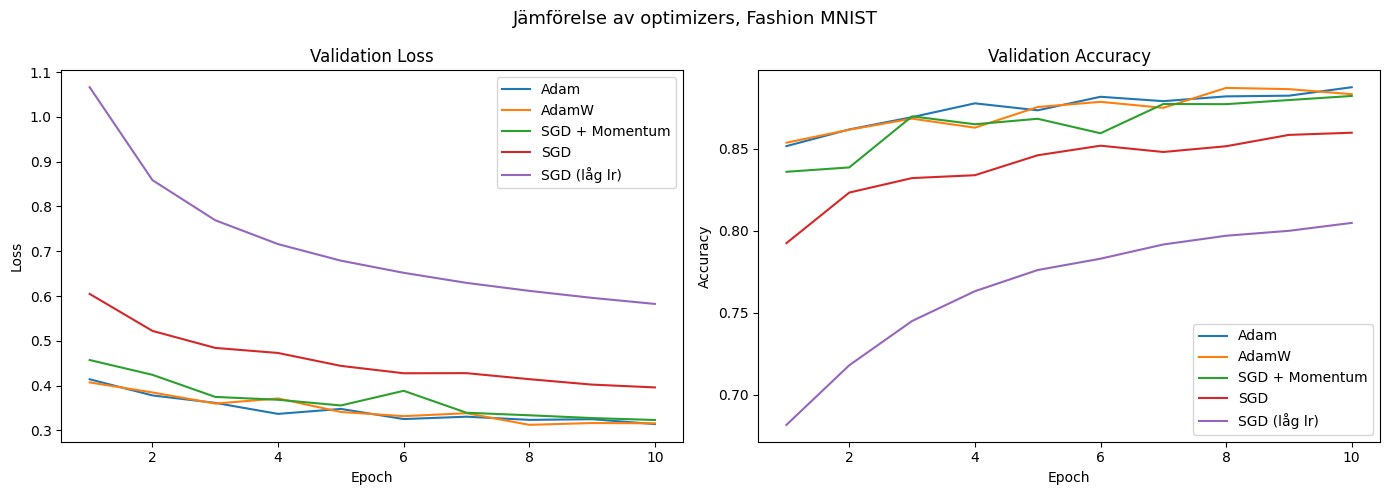

In [22]:
# Träningskurvor för alla optimisers

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss
ax1.plot(epochs, history.history['val_loss'], label='Adam')
ax1.plot(epochs, history_adamw.history['val_loss'], label='AdamW')
ax1.plot(epochs, history_sgd_m.history['val_loss'], label='SGD + Momentum')
ax1.plot(epochs, history_sgd.history['val_loss'], label='SGD')
ax1.plot(epochs, history_sgd_low.history['val_loss'], label='SGD (låg lr)')
ax1.set_title('Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, history.history['val_accuracy'], label='Adam')
ax2.plot(epochs, history_adamw.history['val_accuracy'], label='AdamW')
ax2.plot(epochs, history_sgd_m.history['val_accuracy'], label='SGD + Momentum')
ax2.plot(epochs, history_sgd.history['val_accuracy'], label='SGD')
ax2.plot(epochs, history_sgd_low.history['val_accuracy'], label='SGD (låg lr)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Jämförelse av optimizers, Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()

### CNN-modell
Vi ville även pröva en Convolutional Neural Network (CNN) och jämföra hur den presterar mot vår Dense-modell. Vi använde adam som optimiser och en validation split på 20%, som i våra andra testmodeller. 

CNN är särskilt lämpliga för bilddata eftersom de kan identifiera mönster såsom kanter, former och texturer.
 
Till skillnad från Dense-nätverk:
 
Tar CNN hänsyn till bildens struktur
Kan identifiera lokala mönster
Behöver färre parametrar för bildigenkänning


CNN-modellen uppnådde en test accuracy på cirka 89%, jämfört med Dense-modellens bästa resultat på 87%, etta bekräftar att CNN är bättre lämpad för bildklassificering.
 
Träningsaccuracy är något högre än validation accuracy, vilket indikerar en viss överanpassning.
Från epoch 6 och framåt syns ett tydligt overfitting-mönster: träningsaccuracy fortsatte
stiga mot 93.5 % medan valideringsaccuracy planade ut runt 89 %. Detta är samma mönster som vi såg i Dense-modellen vid 30 epochs. CNN-modellen saknar Dropout, vilket
sannolikt bidrar till overfittingen. Ett naturligt nästa steg vore att lägga till
Dropout och undersöka om det förbättrar generaliseringen.
 
Sammantaget visar resultaten att CNN-modellen presterar bra och är bättre lämpad för bildklassificering än en Dense-modell.
 
 

In [23]:
# Modellarkitektur för CNN
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential()
 
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
 
    return model
 

In [24]:
# Kompilering och träning av CNN
cnn_model = build_cnn_model(input_shape=(28, 28, 1), num_classes=10)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# validation_split=0.2, precis som i våra andra modeller
history_cnn = cnn_model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


c:\DataScientist\DL\DL_gruppuppgift_opt_lr\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7695 - loss: 0.6281 - val_accuracy: 0.8232 - val_loss: 0.4845
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8449 - loss: 0.4243 - val_accuracy: 0.8440 - val_loss: 0.4245
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8677 - loss: 0.3602 - val_accuracy: 0.8672 - val_loss: 0.3604
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8822 - loss: 0.3185 - val_accuracy: 0.8782 - val_loss: 0.3388
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8928 - loss: 0.2911 - val_accuracy: 0.8759 - val_loss: 0.3367
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9013 - loss: 0.2669 - val_accuracy: 0.8882 - val_loss: 0.3083
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9095 - loss: 0.2444 - val_accuracy: 0.8885 - val_loss: 0.3029
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9167 - loss: 0.2231 - val_accurac

In [25]:
#Resultat för CNN
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels) 
print("CNN Test Accuracy:", test_acc)
print("CNN Test Loss:", test_loss)
 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8930 - loss: 0.3237
CNN Test Accuracy: 0.8930000066757202
CNN Test Loss: 0.32372674345970154


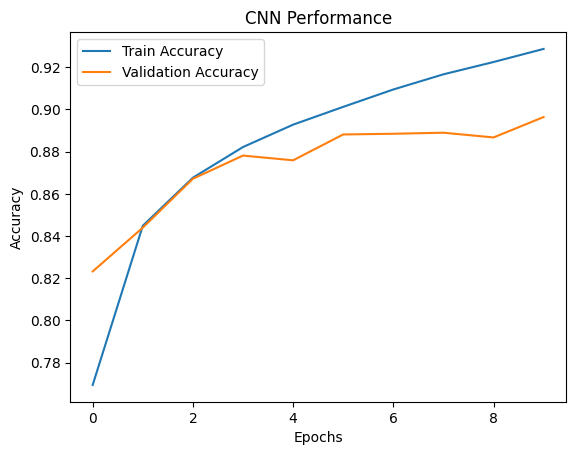

In [26]:
# Visualisering

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
 
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Performance')
plt.legend()
plt.show()

## Spara dense- och CNN-modell

In [27]:
cnn_model.save('cnn_model.keras')
model.save('dense_model.keras')